# En las cumbres de Europa la lista de plantas no se ha acortado. Y cada censo encuentra más huecos.

Las dos cosas caben en los mismos datos, aunque no con la misma fuerza: el alza de riqueza es mínima y se difumina al mirar regiones enteras (Tabla S3), mientras que la proporción de plantas que desaparecen de un cuadro de un metro entre un censo y el siguiente pasó de 11,1% a 15,7% a nivel parcela.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Wessely et al. (2026). *Rising plant extinction rates on European mountain summits*. **Science** 393(6815), 1021-1026.
**DOI:** [10.1126/science.aed2974](https://doi.org/10.1126/science.aed2974)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-03-extincion-plantas-cumbres-europeas/notebook.ipynb)

**Video:** [Pendiente]

## Qué midieron

Hay una red de parcelas fijas repartidas por las cimas de Europa — se llama GLORIA — y lleva desde 2001 volviendo al mismo metro cuadrado a apuntar qué plantas siguen ahí. Este trabajo junta 896 parcelas de 1 m × 1 m en 62 cumbres de 16 regiones y 10 países, desde los Cairngorms escoceses hasta Creta, y desde Sierra Nevada hasta los Cárpatos.

Volvieron a cada parcela cuatro veces —alrededor de 2001, 2008, 2015 y 2022: 17 de las 62 cumbres se salen de ese calendario, con primeros censos entre 1998 y 2003 y segundos hasta 2012, así que los huecos reales entre censos van de 5 a 10 años— y todas están en los primeros cinco metros por debajo de la cima, que es donde viven las plantas más propias de la alta montaña de cada macizo. La elevación mediana de las cumbres es de 2.340 m, y la mitad central está entre 1.996 y 2.773 m.

Nadie manipuló nada: es un remuestreo. Eso marca lo que podemos decir y lo que no — se puede afirmar que dos cosas van juntas, no que una produzca la otra.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
NIVEL_FOCO = 'parcela'           # 'parcela' | 'cumbre' | 'region'
COLOR_EXTINCION    = '#DC2626'   # lo que se va
COLOR_COLONIZACION = '#2563EB'   # lo que llega
COLOR_ESCALA_MEDIA = '#7C3AED'   # nivel cumbre
COLOR_REFERENCIA   = '#D97706'   # nivel región
COLOR_CONTEXTO     = '#BBBBBB'
FUENTE = ('Fuente: Wessely et al. (2026), Science 393:1021 | '
          'Datos: texto del paper y sus Materiales Suplementarios (mismo DOI)')

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
DATOS = 'datos' if os.path.isdir('datos') else '/home/jupyter/datos'
FIGURAS = 'figuras' if os.path.isdir('figuras') else '/home/jupyter/figuras'
os.makedirs(FIGURAS, exist_ok=True)

# Estilo CaM (local → /tmp → GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

cumbres     = pd.read_csv(f'{DATOS}/cumbres_gloria.csv')
ext         = pd.read_csv(f'{DATOS}/extinciones_por_intervalo.csv')
col         = pd.read_csv(f'{DATOS}/colonizaciones_por_intervalo.csv')
modelos     = pd.read_csv(f'{DATOS}/modelos_extincion_vs_colonizacion.csv')
geografia   = pd.read_csv(f'{DATOS}/extincion_geografia.csv')
cobertura   = pd.read_csv(f'{DATOS}/cobertura_predice_extincion.csv')
trayectoria = pd.read_csv(f'{DATOS}/trayectoria_previa_extincion.csv')
conservador = pd.read_csv(f'{DATOS}/conteo_aparente_vs_conservador.csv')

INTERVALOS = ['2001-2008', '2008-2015', '2015-2022']


def es(x, dec=1):
    """Formato numérico español: punto de miles, coma decimal."""
    return f'{x:,.{dec}f}'.replace(',', '@').replace('.', ',').replace('@', '.')


print(f'Cumbres: {len(cumbres)} | regiones: {cumbres.region_montanosa.nunique()} | '
      f'países: {cumbres.pais.nunique()} | parcelas: {es(cumbres.n_parcelas.sum(), 0)}')
print(f'Elevación (m): mediana {es(cumbres.elevacion_m.median(), 0)} | '
      f'IQR {es(cumbres.elevacion_m.quantile(.25), 0)}-'
      f'{es(cumbres.elevacion_m.quantile(.75), 0)} | '
      f'rango {es(cumbres.elevacion_m.min(), 0)}-{es(cumbres.elevacion_m.max(), 0)}')
print(f'Latitud: de {es(cumbres.latitud.min(), 2)} a {es(cumbres.latitud.max(), 2)} grados N')
print(f'Parcelas por cumbre: mediana {cumbres.n_parcelas.median():.0f} | '
      f'rango {cumbres.n_parcelas.min()}-{cumbres.n_parcelas.max()}')

e = ext[ext.nivel_agregacion == NIVEL_FOCO].set_index('intervalo')
c = col[col.nivel_agregacion == NIVEL_FOCO].set_index('intervalo')

print(f'\n--- Nivel de agregación: {NIVEL_FOCO} ---')
for iv in INTERVALOS:
    print(f'{iv}: {es(e.loc[iv, "n_extinciones"], 0):>5} salidas '
          f'({es(e.loc[iv, "pct_observaciones"])}% de las observaciones) | '
          f'{es(c.loc[iv, "n_colonizaciones"], 0):>5} llegadas')

delta_pp = e.loc['2015-2022', 'pct_observaciones'] - e.loc['2001-2008', 'pct_observaciones']
delta_rel = 100 * delta_pp / e.loc['2001-2008', 'pct_observaciones']
print(f'\nExtinción a nivel {NIVEL_FOCO}: +{es(delta_pp)} puntos porcentuales '
      f'= +{es(delta_rel, 0)}% relativo entre el primer y el último intervalo')

Cumbres: 62 | regiones: 16 | países: 10 | parcelas: 896
Elevación (m): mediana 2.340 | IQR 1.996-2.773 | rango 742-3.327
Latitud: de 35,27 a 62,35 grados N
Parcelas por cumbre: mediana 16 | rango 3-16

--- Nivel de agregación: parcela ---
2001-2008:   980 salidas (11,1% de las observaciones) | 1.391 llegadas
2008-2015: 1.266 salidas (13,7% de las observaciones) | 1.284 llegadas
2015-2022: 1.451 salidas (15,7% de las observaciones) | 1.401 llegadas

Extinción a nivel parcela: +4,6 puntos porcentuales = +41% relativo entre el primer y el último intervalo


Aquí está.

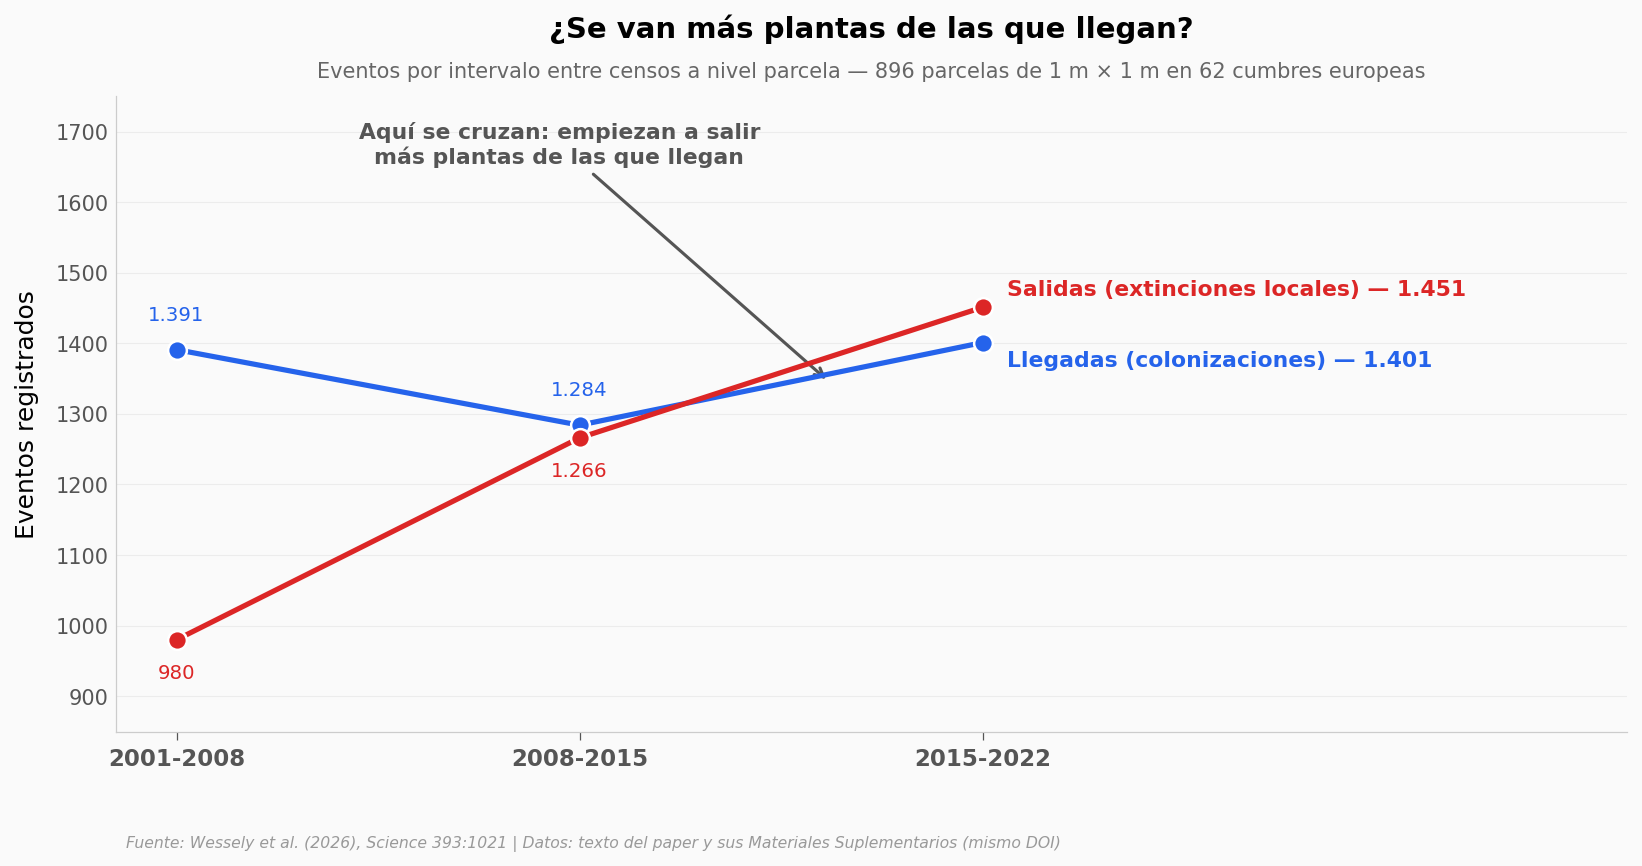

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(INTERVALOS))

y_ext = e.loc[INTERVALOS, 'n_extinciones'].values
y_col = c.loc[INTERVALOS, 'n_colonizaciones'].values

ax.plot(x, y_col, 'o-', color=COLOR_COLONIZACION, linewidth=2.5,
        markersize=9, markeredgecolor='white', markeredgewidth=1.2, zorder=5)
ax.plot(x, y_ext, 'o-', color=COLOR_EXTINCION, linewidth=2.5,
        markersize=9, markeredgecolor='white', markeredgewidth=1.2, zorder=5)

# Inline labels al final de cada serie, en vez de caja de leyenda
ax.text(2.06, y_ext[2] + 25, f'Salidas (extinciones locales) — {es(y_ext[2], 0)}',
        fontsize=10.5, color=COLOR_EXTINCION, fontweight='bold', va='center')
ax.text(2.06, y_col[2] - 25, f'Llegadas (colonizaciones) — {es(y_col[2], 0)}',
        fontsize=10.5, color=COLOR_COLONIZACION, fontweight='bold', va='center')

# Valores de los dos primeros intervalos (el tercero va en la etiqueta de serie)
for xi in (0, 1):
    ax.text(xi, y_ext[xi] - 55, es(y_ext[xi], 0), fontsize=9.5,
            color=COLOR_EXTINCION, ha='center')
    ax.text(xi, y_col[xi] + 42, es(y_col[xi], 0), fontsize=9.5,
            color=COLOR_COLONIZACION, ha='center')

# El cruce
ax.annotate('Aquí se cruzan: empiezan a salir\nmás plantas de las que llegan',
            xy=(1.62, 1345), xytext=(0.95, 1655),
            fontsize=10.5, fontweight='bold', color='#555555', ha='center',
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5))

ax.set_xticks(x)
ax.set_xticklabels(INTERVALOS, fontsize=11, fontweight='bold')
ax.set_xlim(-0.15, 3.6)
ax.set_ylabel('Eventos registrados')
ax.set_ylim(850, 1750)
ax.set_title('¿Se van más plantas de las que llegan?', fontsize=14,
             fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Eventos por intervalo entre censos a nivel {NIVEL_FOCO} — '
        '896 parcelas de 1 m × 1 m en 62 cumbres europeas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig(f'{FIGURAS}/hero_salidas_vs_llegadas.png', dpi=200, bbox_inches='tight')
plt.show()

Las llegadas no marcan tendencia: 1.391, 1.284 y 1.401 a nivel parcela en los tres intervalos, y el modelo no detecta pendiente (p = 0,17). Las salidas suben en cada uno: 980, 1.266 y 1.451. Restando las dos series —cálculo nuestro, no del paper— entre 2015 y 2022 se pierden más plantas de las que entran a nivel parcela (−50) y de región (−4); a nivel de cumbre entera el saldo sigue siendo positivo (+6).

Los modelos del paper separan los dos procesos con claridad. La extinción crece con el tiempo en los tres niveles de agregación (p < 0,001 en todos). La colonización no muestra ninguna tendencia detectable: p = 0,17 a nivel parcela, 0,92 a nivel cumbre y 0,31 a nivel región. Tampoco responde al calentamiento (p = 0,51, 0,61 y 0,21).

Es la parte que se pierde de vista cuando solo se cuenta cuántas especies hay: el saldo puede quedar plano mientras las dos mitades se mueven en direcciones distintas.

## ¿Y si el metro cuadrado engaña?

Una parcela de 1 m × 1 m es una ventana estrecha: una planta puede faltar ahí y seguir viva dos pasos más allá. Por eso el paper repite la cuenta a tres escalas — parcela, cumbre entera y región montañosa — y una especie solo cuenta como perdida si no aparece en ninguna parte de ese nivel.

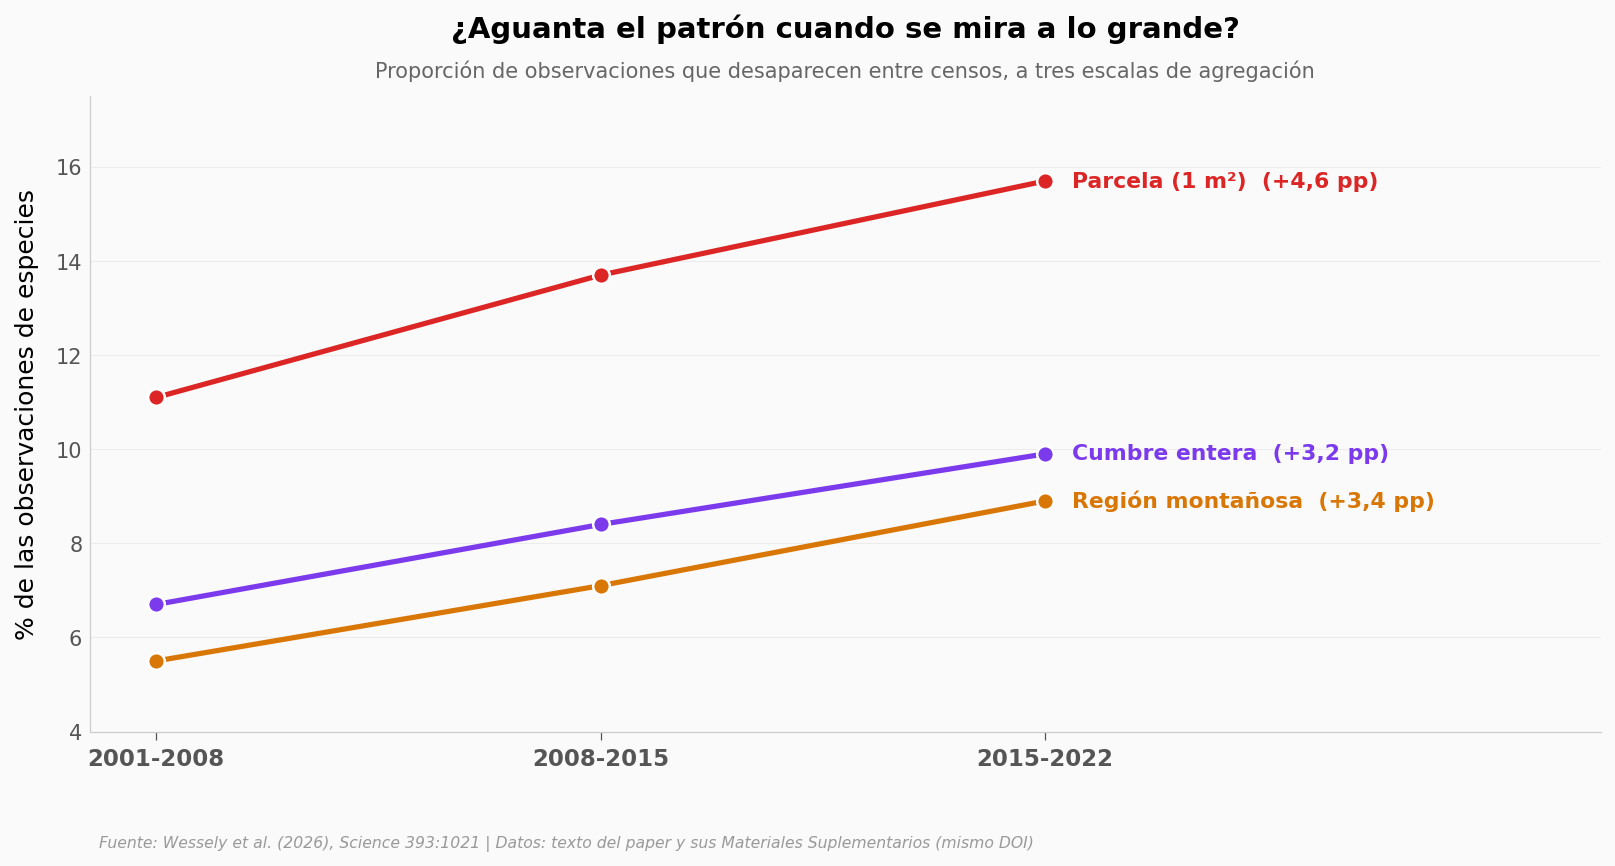


Extinción ~ calentamiento + latitud + longitud (GLMM, Tabla S6)
  latitud @ parcela : coeficiente  -0,42  p = <0,001
  latitud @ cumbre  : coeficiente  -0,17  p = 0,21
  latitud @ region  : coeficiente  -0,07  p = 0,61


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

niveles = [('parcela', COLOR_EXTINCION), ('cumbre', COLOR_ESCALA_MEDIA),
           ('region', COLOR_REFERENCIA)]
etiquetas = {'parcela': 'Parcela (1 m²)', 'cumbre': 'Cumbre entera',
             'region': 'Región montañosa'}

for nivel, color in niveles:
    sub = ext[ext.nivel_agregacion == nivel].set_index('intervalo').loc[INTERVALOS]
    y = sub['pct_observaciones'].values
    ax.plot(x, y, 'o-', color=color, linewidth=2.5, markersize=8,
            markeredgecolor='white', markeredgewidth=1.2, zorder=5)
    salto = y[-1] - y[0]
    ax.text(2.06, y[-1], f'{etiquetas[nivel]}  (+{salto:.1f} pp)'.replace('.', ','),
            fontsize=10.5, color=color, fontweight='bold', va='center')

ax.set_xticks(x)
ax.set_xticklabels(INTERVALOS, fontsize=11, fontweight='bold')
ax.set_xlim(-0.15, 3.25)
ax.set_ylim(4, 17.5)
ax.set_ylabel('% de las observaciones de especies')
ax.set_title('¿Aguanta el patrón cuando se mira a lo grande?', fontsize=14,
             fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Proporción de observaciones que desaparecen entre censos, '
        'a tres escalas de agregación',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig(f'{FIGURAS}/extincion_por_escala.png', dpi=200, bbox_inches='tight')
plt.show()

# El gradiente norte-sur aparece y desaparece según la escala (Tabla S6)
print('\nExtinción ~ calentamiento + latitud + longitud (GLMM, Tabla S6)')
lat = geografia[geografia.predictor == 'Latitud']
for _, r in lat.iterrows():
    print(f'  latitud @ {r.nivel_agregacion:<8}: coeficiente {es(r.estimate, 2):>6}  '
          f'p = {r.p_value.replace(".", ",")}')

El patrón aguanta al subir de escala: la extinción también crece en la cumbre entera y en la región montañosa. Lo que se cae al mirar en grande es el gradiente norte-sur — la latitud pesa en el metro cuadrado (−0,42, p < 0,001) y se apaga por encima (p = 0,21 y 0,61).

## ¿Es el tiempo o es el calor?

Que algo suba año tras año no dice por qué. El paper compara dos modelos con la misma respuesta —¿se extinguió esta especie aquí?— y distinto predictor: el paso del tiempo por un lado, y por otro los grados de calentamiento acumulados en cada cumbre respecto a su clima de 1900-1950.

Lo que comparamos es el R² marginal: cuánta variación captura la parte fija del modelo, la que no viene de las diferencias entre cumbres.

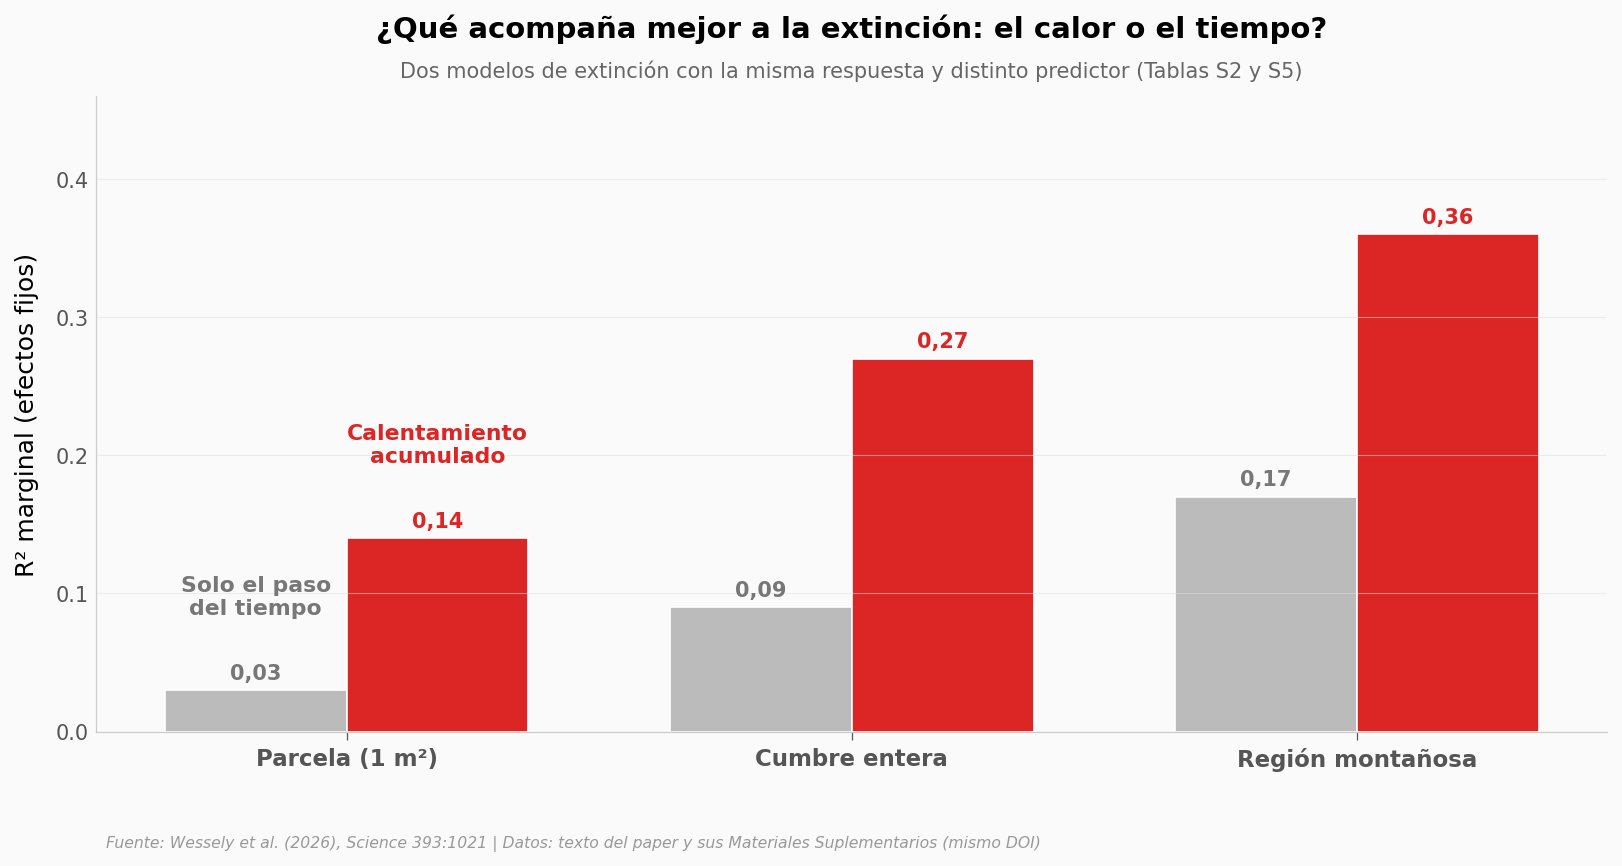


Colonización: ningún modelo alcanza significación (Tablas S10 y S11)
  tiempo         @ parcela : coeficiente   0,02  p = 0,17
  tiempo         @ cumbre  : coeficiente  -0,00  p = 0,92
  tiempo         @ region  : coeficiente  -0,03  p = 0,31
  calentamiento  @ parcela : coeficiente   0,02  p = 0,51
  calentamiento  @ cumbre  : coeficiente   0,04  p = 0,61
  calentamiento  @ region  : coeficiente  -0,07  p = 0,21


In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

orden = ['parcela', 'cumbre', 'region']
ext_mod = modelos[modelos.respuesta == 'extincion']
r2_tiempo = [ext_mod[(ext_mod.predictor_modelo == 'tiempo') &
                     (ext_mod.nivel_agregacion == n)].r2_marginal.iloc[0] for n in orden]
r2_calor = [ext_mod[(ext_mod.predictor_modelo == 'calentamiento') &
                    (ext_mod.nivel_agregacion == n)].r2_marginal.iloc[0] for n in orden]

xb = np.arange(len(orden))
ancho = 0.36
b1 = ax.bar(xb - ancho / 2, r2_tiempo, ancho, color=COLOR_CONTEXTO,
            edgecolor='white', linewidth=0.8)
b2 = ax.bar(xb + ancho / 2, r2_calor, ancho, color=COLOR_EXTINCION,
            edgecolor='white', linewidth=0.8)

for barras, valores, color in [(b1, r2_tiempo, '#777777'), (b2, r2_calor, COLOR_EXTINCION)]:
    for barra, v in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width() / 2, v + 0.008,
                f'{v:.2f}'.replace('.', ','), ha='center', fontsize=10,
                fontweight='bold', color=color)

ax.text(xb[0] - ancho / 2, r2_tiempo[0] + 0.055, 'Solo el paso\ndel tiempo',
        ha='center', fontsize=10.5, color='#777777', fontweight='bold')
ax.text(xb[0] + ancho / 2, r2_calor[0] + 0.055, 'Calentamiento\nacumulado',
        ha='center', fontsize=10.5, color=COLOR_EXTINCION, fontweight='bold')

ax.set_xticks(xb)
ax.set_xticklabels(['Parcela (1 m²)', 'Cumbre entera', 'Región montañosa'],
                   fontsize=11, fontweight='bold')
ax.set_ylabel('R² marginal (efectos fijos)')
ax.set_ylim(0, 0.46)
ax.set_title('¿Qué acompaña mejor a la extinción: el calor o el tiempo?', fontsize=14,
             fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Dos modelos de extinción con la misma respuesta y distinto '
        'predictor (Tablas S2 y S5)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig(f'{FIGURAS}/tiempo_vs_calentamiento.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nColonización: ningún modelo alcanza significación (Tablas S10 y S11)')
col_mod = modelos[modelos.respuesta == 'colonizacion']
for _, r in col_mod.iterrows():
    print(f'  {r.predictor_modelo:<14} @ {r.nivel_agregacion:<8}: '
          f'coeficiente {es(r.estimate, 2):>6}  p = {str(r.p_value).replace(".", ",")}')

## ¿Se veía venir?

Esta es la parte que más se puede usar. Antes de desaparecer, la mayoría de estas plantas llevaba años menguando: de las extinciones registradas en 2022, el 57,6% venía de una trayectoria de cobertura en declive, el 32,2% de una en aumento y el 10,2% de cobertura constante.

El paper va un paso más allá y cuenta cuántas de esas trayectorias eran un declive continuo, sin repuntes. Observó 112,8 ± 2,7 de media contra las 44,5 ± 6,5 que esperaría el azar: 2,5 veces más, unas 10,5 desviaciones por encima de la media del azar. El paper no publica sobre cuántas trayectorias se cuentan esas 112,8, así que es un conteo sin denominador a la vista.

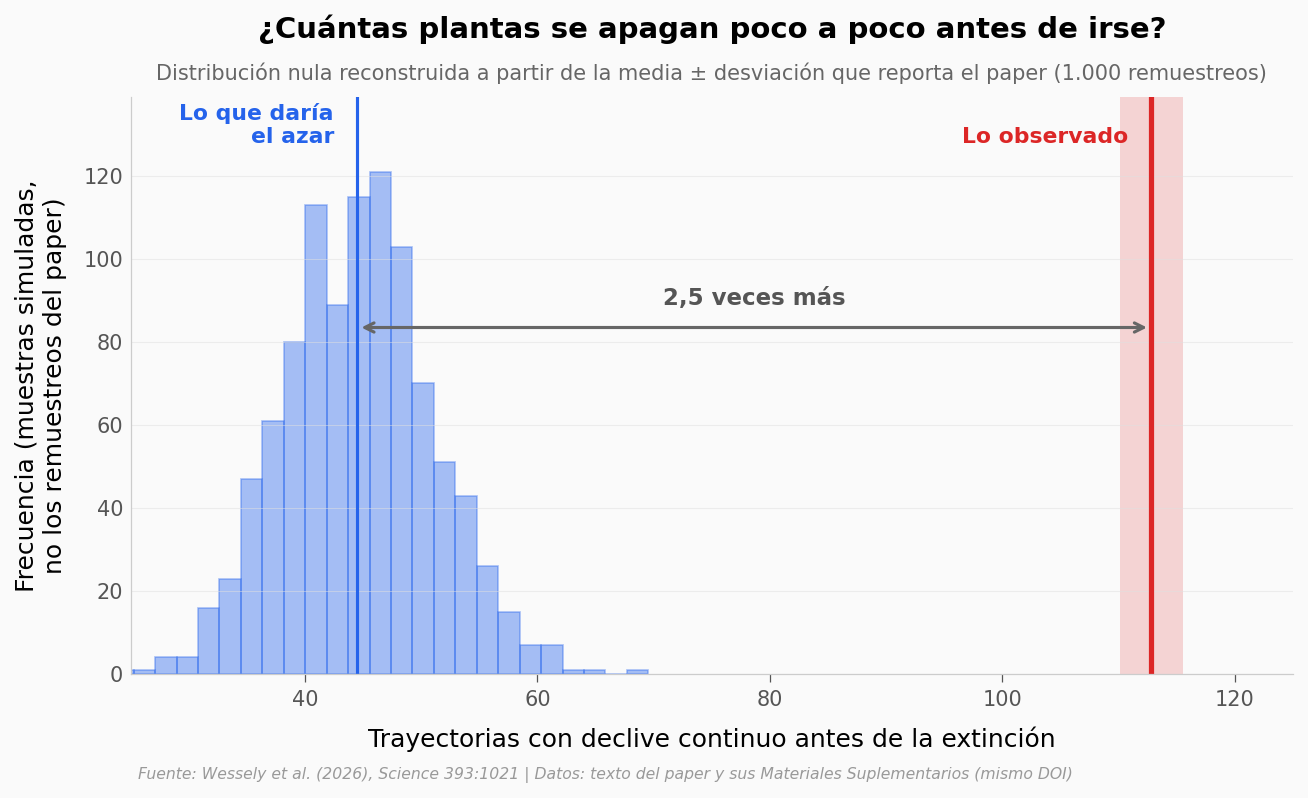

Observado: 112,8 ± 2,7 | azar: 44,5 ± 6,5 | ratio 2,5x
Prueba del paper: t de Student, gl = 1.333.209, P < 0,001

Modelos de aviso temprano: extinción ~ cambio previo de cobertura (Tabla S7)
  [7 años] R² marginal = 0,58
      Cambio medio de cobertura (7 a)    coeficiente  -1,24  p = <0,001
      Cobertura 2008                     coeficiente  -2,72  p = <0,001
  [14 años] R² marginal = 0,60
      Cambio medio de cobertura (14 a)   coeficiente  -1,50  p = <0,001
      Cobertura 2001                     coeficiente  -2,77  p = <0,001
  [14 años + rango + termof.] R² marginal = 0,75
      Cambio medio de cobertura (14 a)   coeficiente  -2,06  p = <0,001
      Cobertura 2001                     coeficiente  -3,90  p = <0,001
      Rango elevacional relativo         coeficiente   0,16  p = 0,01
      Termofilización                    coeficiente   0,18  p = 0,04


In [5]:
# ── Métrica reconstruida (no son los remuestreos originales) ──────────────
# El paper reporta media ± desviación de dos cantidades: trayectorias de declive
# continuo observadas (112,8 ± 2,7) y esperadas por azar (44,5 ± 6,5). Aquí
# reconstruimos la distribución nula como una normal con esos dos parámetros.
# Es una aproximación paramétrica para ver la distancia, no el remuestreo del paper.
np.random.seed(42)
N_RESAMPLES = 1000
AZAR_MEDIA, AZAR_SD = 44.5, 6.5
OBSERVADO, OBSERVADO_SD = 112.8, 2.7

nulo = np.random.normal(AZAR_MEDIA, AZAR_SD, N_RESAMPLES)

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(nulo, bins=25, color=COLOR_COLONIZACION, alpha=0.4,
                           edgecolor=COLOR_COLONIZACION, linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)
ax.set_xlim(25, 125)

ax.axvline(x=AZAR_MEDIA, color=COLOR_COLONIZACION, linewidth=1.5)
ax.axvspan(OBSERVADO - OBSERVADO_SD, OBSERVADO + OBSERVADO_SD,
           color=COLOR_EXTINCION, alpha=0.18, linewidth=0)
ax.axvline(x=OBSERVADO, color=COLOR_EXTINCION, linewidth=2.5)
ax.annotate('', xy=(OBSERVADO, y_max * 0.6), xytext=(AZAR_MEDIA, y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((AZAR_MEDIA + OBSERVADO) / 2, y_max * 0.64,
        f'{OBSERVADO / AZAR_MEDIA:.1f} veces más'.replace('.', ','),
        ha='center', fontsize=11, fontweight='bold', color='#555555')
ax.text(AZAR_MEDIA - 2, y_max * 0.92, 'Lo que daría\nel azar', ha='right',
        fontsize=10.5, color=COLOR_COLONIZACION, fontweight='bold')
ax.text(OBSERVADO - 2, y_max * 0.92, 'Lo observado', ha='right',
        fontsize=10.5, color=COLOR_EXTINCION, fontweight='bold')

ax.set_xlabel('Trayectorias con declive continuo antes de la extinción')
ax.set_ylabel('Frecuencia (muestras simuladas,\nno los remuestreos del paper)')
ax.set_title('¿Cuántas plantas se apagan poco a poco antes de irse?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución nula reconstruida a partir de la media ± desviación '
        'que reporta el paper (1.000 remuestreos)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig(f'{FIGURAS}/anomalia_declive_previo.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Observado: {es(OBSERVADO)} ± {es(OBSERVADO_SD)} | '
      f'azar: {es(AZAR_MEDIA)} ± {es(AZAR_SD)} '
      f'| ratio {es(OBSERVADO / AZAR_MEDIA)}x')
print('Prueba del paper: t de Student, gl = 1.333.209, P < 0,001\n')

print('Modelos de aviso temprano: extinción ~ cambio previo de cobertura (Tabla S7)')
for modelo in cobertura.modelo.unique():
    sub = cobertura[cobertura.modelo == modelo]
    print(f'  [{modelo}] R² marginal = {es(sub.r2_marginal.iloc[0], 2)}')
    for _, r in sub.iterrows():
        print(f'      {r.predictor:<34} coeficiente {es(r.estimate, 2):>6}  '
              f'p = {str(r.p_value).replace(".", ",")}')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Las extinciones locales aumentaron en los 21 años | ✅ | A nivel parcela, de 11,1% a 15,7% de las observaciones: +4,6 puntos porcentuales, +41% relativo. El modelo extinción ~ tiempo da p < 0,001 en los tres niveles (Tablas S1 y S2) |
| Las colonizaciones no siguen la misma trayectoria | ✅ | 1.391 → 1.284 → 1.401 a nivel parcela. Ningún modelo de colonización alcanza significación: p = 0,17 / 0,92 / 0,31 frente al tiempo y 0,51 / 0,61 / 0,21 frente al calentamiento (Tablas S9-S11) |
| El calentamiento acompaña la extinción mejor que el paso del tiempo | ⚠️ | R² marginal 0,14 / 0,27 / 0,36 contra 0,03 / 0,09 / 0,17 (Tablas S2 y S5). El calentamiento se **midió**, no se asignó: es el argumento del paper, no un experimento. Y son dos ajustes por separado con predictores distintos, no una comparación formal de modelos |
| Cada 0,1 °C más de calentamiento va acompañado de 1,6 / 1,1 / 1,0 puntos porcentuales más de extinciones | ⚠️ | Cifra citada del texto del paper para los niveles parcela / cumbre / región; no está en los CSVs de este notebook. Es una pendiente de modelo sobre datos observacionales: el calentamiento se midió, no se asignó |
| El declive previo de cobertura anticipa la extinción | ✅ | Con ventana de 14 años, coeficiente −1,50 y R² marginal 0,60; el modelo que añade el tramo de altitud donde vive cada especie y la termofilización (que la comunidad se vaya llenando de especies de climas más cálidos) llega a 0,75 ± 0,042 (Tabla S7). El 57,6% de las extinciones de 2022 venía de una cobertura en declive |
| Las trayectorias de declive continuo son 2,5 veces más de las que daría el azar | ⚠️ | El paper reporta 112,8 ± 2,7 observadas contra 44,5 ± 6,5 esperadas (t de Student, gl = 1.333.209, P < 0,001). La distribución de la última gráfica es una **reconstrucción paramétrica** desde esa media y esa desviación, no los remuestreos originales |
| Hay más especies en las cumbres que al principio | ⚠️ | El paper modela la riqueza (Tabla S3): a nivel parcela sube +0,01 con p = 0,008; a nivel región p = 0,168, es decir, no significativo. Esas tres cifras están citadas del PDF y no se pueden reproducir con los CSVs de este notebook. El saldo llegadas − salidas que se puede calcular con los datos de aquí (+411, +18 y −50 a nivel parcela) es **cálculo nuestro**, no un resultado de los autores |
| "Extinción" aquí no significa que la especie se haya acabado | ✅ | Es una ausencia local: no reobservada en el censo siguiente en ese nivel. El paper reporta que el 34,2% ± 0,2 de las extinciones a nivel parcela fue seguido de una reaparición posterior; esa cifra y la cuenta conservadora del apartado de limitaciones no se refieren al mismo conjunto de extinciones, así que no se restan entre sí |

> **Limitaciones:**
>
> - **Diseño observacional.** Cuatro censos de parcelas fijas, sin manipulación ni asignación. Todo lo de arriba describe cosas que van juntas, no cadenas de causa.
> - **Extinción local ≠ extinción de la especie.** Una planta puede desaparecer del cuadro muestreado y seguir viva al lado. El propio paper lo dice, y el 34,2% de reapariciones a nivel parcela lo confirma: parte de esas ausencias son fluctuación real, ausencia aérea ese año o error de observación.
> - **Contar diferente cambia la magnitud, pero no son la misma cuenta.** Si solo se cuentan las ausencias definitivas —especies que no vuelven en ningún censo posterior—, la cifra a nivel parcela baja de 15,7% a 6,5%. Las dos las reporta el paper, pero **no salen del mismo conjunto de observaciones**: los denominadores implícitos no coinciden (1.451 sobre 15,7% da unas 9.242 observaciones; 578 sobre 6,5%, unas 8.892), y una ausencia solo puede declararse definitiva si hay censos posteriores, cosa que el intervalo 2015-2022 no tiene. La celda experimental de más abajo las pone lado a lado, pero no son la misma pérdida contada dos veces.
> - **Los datos originales no están publicados.** El depósito de Dryad que cita el paper (10.5061/dryad.vmcvdnd6v) devuelve 404, y Science emitió una corrección el 2026-09-04 declarándolo. Todo lo de este notebook viene del texto del paper y de su PDF de Materiales Suplementarios.
> - **Sospecha de error de extracción en una fila.** En la Tabla S10, la fila de colonización ~ tiempo a nivel región repite exactamente los R² de la fila de extinción ~ tiempo a ese mismo nivel (0,17 y 0,81), lo que es incompatible con su p = 0,31. La sospecha alcanza solo a los R² —el estimate y el p de esa fila no están duplicados—, y por eso la gráfica de R² usa solo los modelos de extinción.
> - **Las parcelas por cumbre van de 3 a 16** (mediana 16). Promediar entre cumbres sin ponderar mezcla resoluciones distintas.
> - **Una cumbre (Zinken-NW-summit, Austria) tiene el primer censo repartido en dos años** ('1998/2002' en la Tabla S8), por eso esa columna se lee como texto y no como número.

## Ahora tú

**1. ¿El patrón aguanta si una "observación" es un macizo entero?** La celda de configuración arranca en `NIVEL_FOCO = 'parcela'`. Cámbialo a `'region'` y vuelve a correr desde ahí: la gráfica hero se rehace sola con los 16 macizos.

**2. ¿Pierden más las cumbres bajas de cada región?** `cumbres_gloria.csv` trae elevación, latitud y longitud de las 62 cimas. Pista: `cumbres.groupby('region_montanosa').elevacion_m.agg(['min', 'max', 'count'])` para ver el rango interno de cada macizo.

**3. ¿Por qué el gradiente norte-sur solo aparece en el metro cuadrado?** La latitud pesa a nivel parcela (coeficiente −0,42, p < 0,001) y se apaga en cumbre (p = 0,21) y región (p = 0,61). Pista: `geografia[geografia.predictor == 'Latitud']`. ¿Es biología del sur de Europa o es que a escala gruesa quedan menos observaciones para detectarlo?

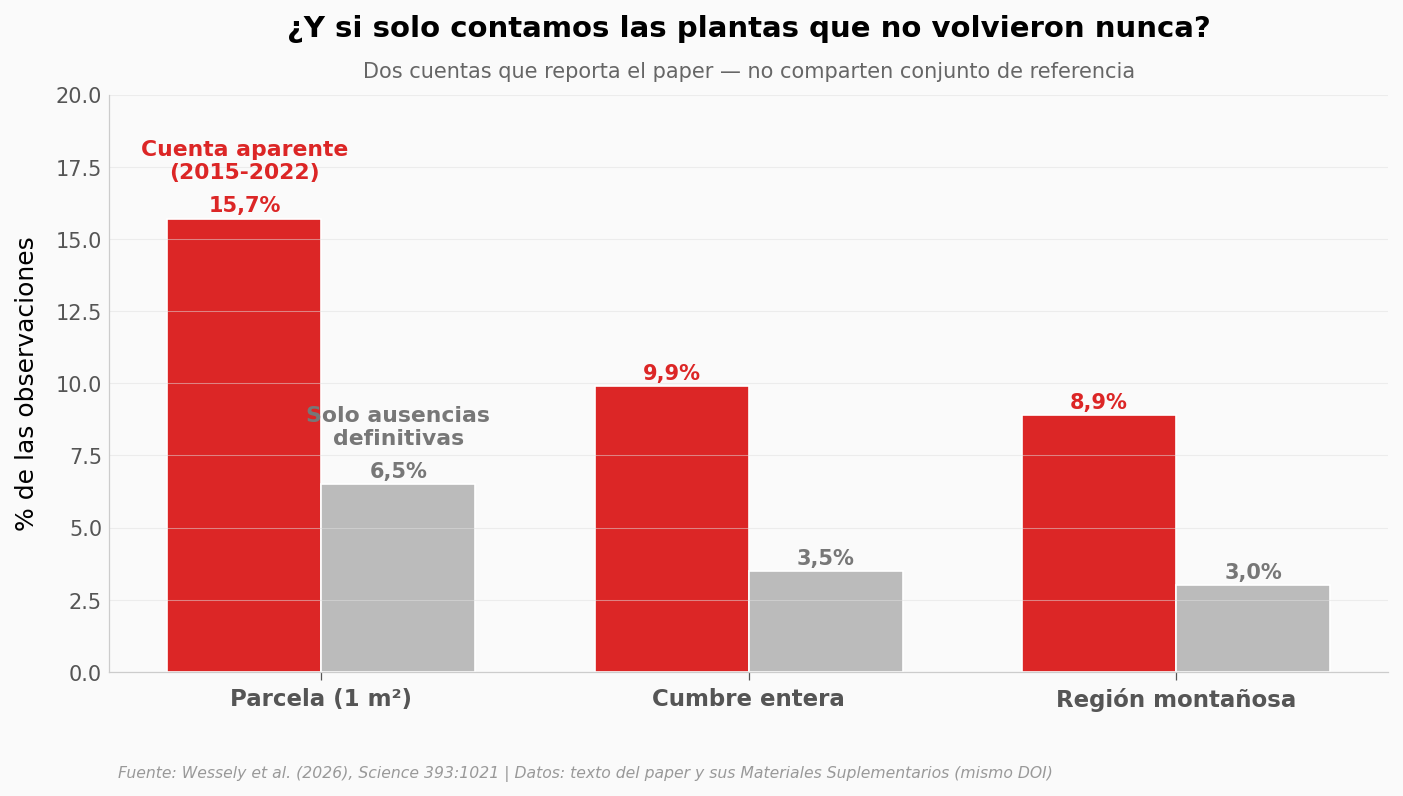

parcela : 15,7% aparente vs  6,5% conservador  (2,4x)
cumbre  :  9,9% aparente vs  3,5% conservador  (2,8x)
region  :  8,9% aparente vs  3,0% conservador  (3,0x)


In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánto cambia el retrato si solo contamos las ausencias definitivas?
# OJO: no es la misma cuenta hecha dos veces. Los denominadores implícitos no
# coinciden y la cuenta conservadora necesita censos posteriores, que el
# intervalo 2015-2022 no tiene. Son dos cifras del paper, puestas lado a lado.
# "Aparente" = no reobservada en el censo siguiente.
# "Conservador" = ausente en todos los censos posteriores. Ambas cuentas
# están en el texto del paper (sección de resultados).

fig, ax = plt.subplots(figsize=(11, 5))
xb = np.arange(len(conservador))
ancho = 0.36

ax.bar(xb - ancho / 2, conservador.pct_aparente_2015_2022, ancho,
       color=COLOR_EXTINCION, edgecolor='white', linewidth=0.8)
ax.bar(xb + ancho / 2, conservador.pct_conservador, ancho,
       color=COLOR_CONTEXTO, edgecolor='white', linewidth=0.8)

for xi, (a, c_) in enumerate(zip(conservador.pct_aparente_2015_2022,
                                 conservador.pct_conservador)):
    ax.text(xi - ancho / 2, a + 0.25, f'{a:.1f}%'.replace('.', ','), ha='center',
            fontsize=10, fontweight='bold', color=COLOR_EXTINCION)
    ax.text(xi + ancho / 2, c_ + 0.25, f'{c_:.1f}%'.replace('.', ','), ha='center',
            fontsize=10, fontweight='bold', color='#777777')

ax.text(xb[0] - ancho / 2, conservador.pct_aparente_2015_2022[0] + 1.4,
        'Cuenta aparente\n(2015-2022)', ha='center', fontsize=10.5,
        color=COLOR_EXTINCION, fontweight='bold')
ax.text(xb[0] + ancho / 2, conservador.pct_conservador[0] + 1.4,
        'Solo ausencias\ndefinitivas', ha='center', fontsize=10.5,
        color='#777777', fontweight='bold')

ax.set_xticks(xb)
ax.set_xticklabels(['Parcela (1 m²)', 'Cumbre entera', 'Región montañosa'],
                   fontsize=11, fontweight='bold')
ax.set_ylabel('% de las observaciones')
ax.set_ylim(0, 20)
ax.set_title('¿Y si solo contamos las plantas que no volvieron nunca?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Dos cuentas que reporta el paper — no comparten conjunto de referencia',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.show()

for _, r in conservador.iterrows():
    ratio = r.pct_aparente_2015_2022 / r.pct_conservador
    print(f'{r.nivel_agregacion:<8}: {es(r.pct_aparente_2015_2022):>4}% aparente vs '
          f'{es(r.pct_conservador):>4}% conservador  ({es(ratio)}x)')

## Fuentes

**Paper**: [Rising plant extinction rates on European mountain summits](https://doi.org/10.1126/science.aed2974)  
*Science, 2026-09-03*

**Supplementary Material**: [Tablas S1-S12 del mismo DOI](https://www.science.org/doi/suppl/10.1126/science.aed2974/suppl_file/science.aed2974_sm.pdf)  
*Los ocho CSV de `datos/` salen de ahí y del texto del artículo. El depósito Dryad que cita el paper (10.5061/dryad.vmcvdnd6v) no está publicado — corrección de Science del 2026-09-04.*

*17 afirmaciones del notebook verificadas contra estas fuentes*